Name: **Robb Ryan P. Calvez**  
Year & Section: **BS CpE 3A**  
Course: **Computer Engineering - Artificial Intelligence / Machine Learning**

**ASSESSMENT 2 - Insurance Regression Problem**


---

#### **Step 1: Import Libraries**

In [326]:
import tensorflow as tf 
import pandas as pd 
import numpy as np 
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print(f'tensorflow: {tf.__version__}\n', 
      f'pandas: {pd.__version__}\n',
      f'numpy: {np.__version__}\n',
      f'sklearn: {sklearn.__version__}')

tensorflow: 2.21.0
 pandas: 3.0.2
 numpy: 2.4.2
 sklearn: 1.8.0


#### **Step 2: Prep Dataset**

Load .csv file.

In [327]:
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")

insurance.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


One hot encode all non-numerical data.

In [328]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int)

features_partial = encoder.fit_transform(insurance[['sex', 'smoker', 'region']])
features_name = encoder.get_feature_names_out(['sex', 'smoker', 'region'])

encoded_partial = pd.DataFrame(features_partial, columns=features_name)

encoded_insurance = pd.concat([insurance.drop(columns=['sex', 'smoker', 'region']), encoded_partial], axis=1)

encoded_insurance.head(10)

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0
5,31,25.740,0,3756.62160,1,0,1,0,0,0,1,0
6,46,33.440,1,8240.58960,1,0,1,0,0,0,1,0
7,37,27.740,3,7281.50560,1,0,1,0,0,1,0,0
8,37,29.830,2,6406.41070,0,1,1,0,1,0,0,0
9,60,25.840,0,28923.13692,1,0,1,0,0,1,0,0


Initialize features (x) and labels (y).

In [329]:
x = encoded_insurance.drop(columns=['charges'])
y = encoded_insurance['charges']

x.head(3), y.head(5)

(   age    bmi  children  sex_female  sex_male  smoker_no  smoker_yes  \
 0   19  27.90         0           1         0          0           1   
 1   18  33.77         1           0         1          1           0   
 2   28  33.00         3           0         1          1           0   
 
    region_northeast  region_northwest  region_southeast  region_southwest  
 0                 0                 0                 0                 1  
 1                 0                 0                 1                 0  
 2                 0                 0                 1                 0  ,
 0    16884.92400
 1     1725.55230
 2     4449.46200
 3    21984.47061
 4     3866.85520
 Name: charges, dtype: float64)

Split dataset into training and testing sets.

In [330]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    random_state=42
                                                    )

Normalize data using `StandardScaler()`

In [331]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train_scaled, x_test_scaled

(array([[ 0.47222651, -1.75652513,  0.73433626, ...,  1.78316783,
         -0.59966106, -0.5723141 ],
        [ 0.54331294, -1.03308239, -0.91119211, ..., -0.56079971,
         -0.59966106, -0.5723141 ],
        [ 0.8987451 , -0.94368672, -0.91119211, ..., -0.56079971,
          1.66760869, -0.5723141 ],
        ...,
        [ 1.3252637 , -0.89153925, -0.91119211, ..., -0.56079971,
         -0.59966106, -0.5723141 ],
        [-0.16755139,  2.82086429,  0.73433626, ..., -0.56079971,
         -0.59966106,  1.74729228],
        [ 1.1120044 , -0.10932713, -0.91119211, ..., -0.56079971,
         -0.59966106,  1.74729228]], shape=(1070, 11)),
 array([[ 0.40114007, -0.89153925,  0.73433626, ..., -0.56079971,
         -0.59966106, -0.5723141 ],
        [-0.23863782, -0.08946143, -0.91119211, ...,  1.78316783,
         -0.59966106, -0.5723141 ],
        [ 1.75178229, -0.60845296, -0.91119211, ...,  1.78316783,
         -0.59966106, -0.5723141 ],
        ...,
        [-0.09646495, -0.41972876, -

#### **Step 3: Build the Model**

In [332]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[11]),
    tf.keras.layers.Dense(128, activation='relu'),    
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(loss='mae',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['mae']
              )

In [333]:
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_82 (Dense)                │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,849 (42.38 KB)

 Trainable params: 10,849 (42.38 KB)

 Non-trainable params: 0 (0.00 B)

In [334]:
history = model.fit(x_train_scaled, y_train,
                    epochs=800,
                    validation_split=0.2
                    )

Epoch 1/800


I0000 00:00:1778776649.647925   58351 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_643554__.10


19/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14542.4144 - mae: 14542.4144

I0000 00:00:1778776651.506116   58351 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_643554__.10


27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 13517.1240 - mae: 13517.1240 - val_loss: 12651.1865 - val_mae: 12651.1865
Epoch 2/800
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 13508.1738 - mae: 13508.1738 - val_loss: 12635.1748 - val_mae: 12635.1748
Epoch 3/800
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 13477.7842 - mae: 13477.7842 - val_loss: 12584.1016 - val_mae: 12584.1016
Epoch 4/800
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 13391.3115 - mae: 13391.3115 - val_loss: 12453.4473 - val_mae: 12453.4473
Epoch 5/800
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 13190.8164 - mae: 13190.8164 - val_loss: 12173.0293 - val_mae: 12173.0293
Epoch 6/800
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12791.3701 - mae: 12791.3701 - val_loss: 11645.9023 - val_mae: 11645.9023
Epoch 7/800
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12084.1191 - mae: 12084.1191 - val_loss: 10795.4170 - val_mae: 10795.4170
Epoch 8/800
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 11038.1973 - mae: 1

Evaluate the model.

In [335]:
evalu = model.evaluate(x_test_scaled, y_test)
evalu

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 1344.0077 - mae: 1344.0077


[1344.0076904296875, 1344.0076904296875]

#### Step 4: Display Results

Loss and MSE History Plot

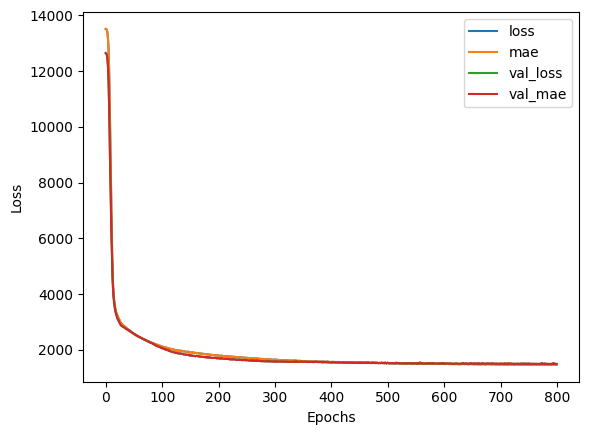

In [336]:
pd.DataFrame(history.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

Compare Prediction to Sample

In [337]:
test_data = pd.concat([x_test, y_test], axis=1)

prediction = model.predict(x_test_scaled)

df_pred = pd.DataFrame(prediction, columns=['charges (PREDICTION RESULT)'])

pred_data = pd.concat([x_test.reset_index(drop=True), df_pred], axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


Sample Test Data:

In [338]:
# Note: Indexes have been reset to 0 for easy viewing and to accomodate the prediction's new indices
(test_data.reset_index(drop=True)).head(20)

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest,charges
0,45,25.175,2,1,0,1,0,1,0,0,0,9095.06825
1,36,30.020,0,1,0,1,0,0,1,0,0,5272.17580
2,64,26.885,0,1,0,0,1,0,1,0,0,29330.98315
3,46,25.745,3,0,1,1,0,0,1,0,0,9301.89355
4,19,31.920,0,0,1,0,1,0,1,0,0,33750.29180
5,34,42.900,1,0,1,1,0,0,0,0,1,4536.25900
6,19,22.515,0,1,0,1,0,0,1,0,0,2117.33885
7,64,37.905,0,0,1,1,0,0,1,0,0,14210.53595
8,28,17.290,0,1,0,1,0,1,0,0,0,3732.62510
9,49,28.690,3,0,1,1,0,0,1,0,0,10264.44210


Prediction Result:

In [339]:
# Note: Indexes have been reset to 0 for easy viewing and to accomodate the prediction's new indices
pred_data.head(20)

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest,charges (PREDICTION RESULT)
0,45,25.175,2,1,0,1,0,1,0,0,0,9047.987305
1,36,30.020,0,1,0,1,0,0,1,0,0,5249.819336
2,64,26.885,0,1,0,0,1,0,1,0,0,29296.193359
3,46,25.745,3,0,1,1,0,0,1,0,0,9307.492188
4,19,31.920,0,0,1,0,1,0,1,0,0,33392.976562
5,34,42.900,1,0,1,1,0,0,0,0,1,4665.032227
6,19,22.515,0,1,0,1,0,0,1,0,0,2301.434082
7,64,37.905,0,0,1,1,0,0,1,0,0,14276.876953
8,28,17.290,0,1,0,1,0,1,0,0,0,3911.341064
9,49,28.690,3,0,1,1,0,0,1,0,0,10301.407227


Sampled vs Predicted Values Comparison Graph:

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


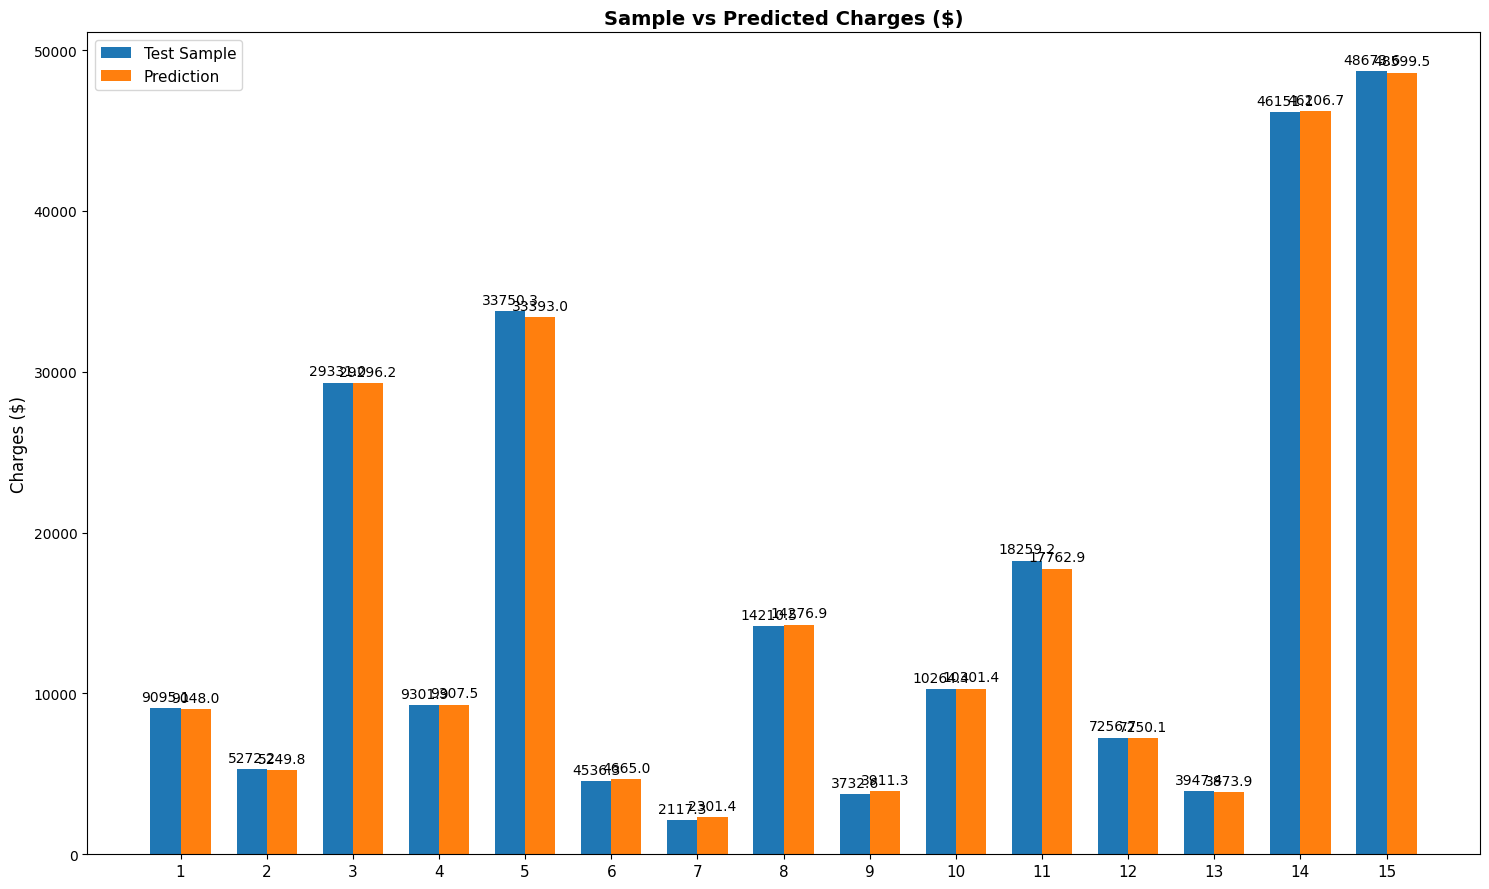

In [341]:
predictions = model.predict(x_test_scaled).flatten()
num = 15 # amount of samples to compare

labels = [f"{i+1}" for i in range(len(np.array(y_test[0:num])))]
x = np.arange(len(labels))  
width = 0.35

fig, ax = plt.subplots(figsize=(15, 9))

bars_test = ax.bar(x - width/2, np.array(y_test[0:num]), width, label='Test Sample', color='#1f77b4')
bars_pred = ax.bar(x + width/2, predictions[0:num], width, label='Prediction', color='#ff7f0e')

ax.set_ylabel('Charges ($)', fontsize=12)
ax.set_title('Sample vs Predicted Charges ($)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=11)

ax.bar_label(bars_test, padding=3, fmt='%.1f')
ax.bar_label(bars_pred, padding=3, fmt='%.1f')

fig.tight_layout()

plt.show()